In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

#  Data Integration

Menggabungkan seluruh dataset e-commerce (orders, customers, products, payments, reviews, sellers, dan geolocation) menjadi satu dataframe utama yang akan digunakan pada seluruh analisis.

In [ ]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("orderitems.csv")
payments = pd.read_csv("payments.csv")
reviews = pd.read_csv("orderreview.csv")
sellers = pd.read_csv("sellers.csv")


In [4]:
df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [5]:
df = df.merge(
    order_items,
    on="order_id",
    how="left"
)

In [6]:
df = df.merge(
    sellers,
    on="seller_id",
    how="left"
)

In [7]:
payments_group = payments.groupby("order_id").agg({
    "payment_sequential":"max",
    "payment_installments":"max",
    "payment_value":"sum",
    "payment_type":lambda x: ', '.join(x.unique())
}).reset_index()

df = df.merge(
    payments_group,
    on="order_id",
    how="left"
)

In [8]:
reviews_group = reviews.groupby("order_id").agg({
    "review_score":"mean",
    "review_comment_title":"first",
    "review_comment_message":"first",
    "review_creation_date":"first",
    "review_answer_timestamp":"first"
}).reset_index()

df = df.merge(
    reviews_group,
    on="order_id",
    how="left"
)

In [9]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
    "review_answer_timestamp"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Cleansing

Bertujuan untuk meningkatkan kualitas data, meliputi identifikasi outlier dan impute missing value.

In [10]:
(df.isnull().mean()*100).sort_values(ascending=False)

review_comment_title             88.091691
review_comment_message           57.685695
order_delivered_customer_date     2.846815
order_delivered_carrier_date      1.735067
review_score                      0.847256
review_creation_date              0.847256
review_answer_timestamp           0.847256
shipping_limit_date               0.683271
seller_id                         0.683271
price                             0.683271
product_id                        0.683271
order_item_id                     0.683271
seller_state                      0.683271
freight_value                     0.683271
seller_city                       0.683271
seller_zip_code_prefix            0.683271
order_approved_at                 0.141944
payment_sequential                0.002645
payment_installments              0.002645
payment_type                      0.002645
payment_value                     0.002645
customer_city                     0.000000
customer_id                       0.000000
customer_st

## Cek Outlier

In [57]:
df['review_score'].value_counts() 
# nilai 3,3 dan 4,3 adalah kesalahan input ketika pengambilan data karena jumlahnya yang hanya 1

review_score
5.000000    62875
4.000000    21040
1.000000    12436
3.000000     9201
2.000000     3660
4.500000       67
2.500000       41
3.500000       29
1.500000       18
3.333333        1
4.333333        1
Name: count, dtype: int64

### Untuk setiap kolom numerik akan dicek menggunakan boxplot untuk identifikasi apakah ada outlier atau tidak
### Jika ada outlier, maka missing value akan diimpute dengan median, dan jika tidak ada akan diimpute dengan mean

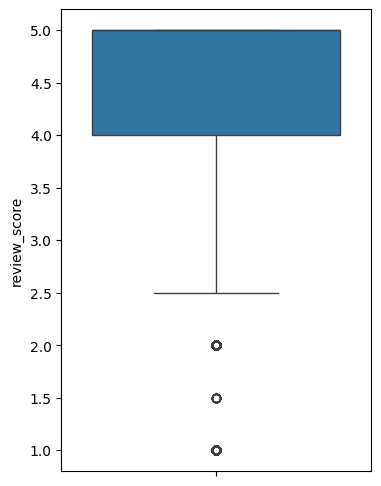

In [12]:
plt.figure(figsize=(4,6))
sns.boxplot(y=df['review_score'])
plt.show()

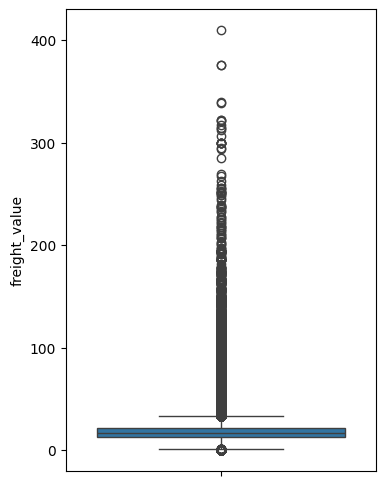

In [14]:
plt.figure(figsize=(4,6))
sns.boxplot(y=df['freight_value'])
plt.show()

In [15]:
df['freight_value'] = df['freight_value'].fillna(df['freight_value'].mean())

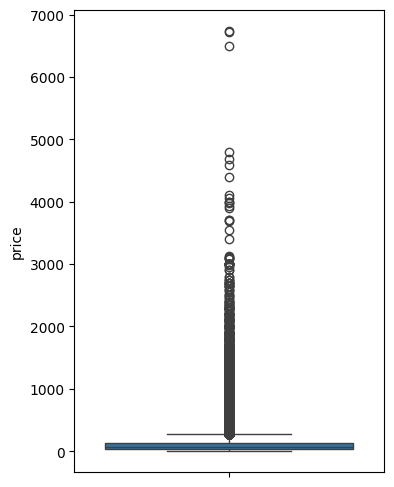

In [16]:
plt.figure(figsize=(4,6))
sns.boxplot(y=df['price'])
plt.show()

In [17]:
df['price'] = df['price'].fillna(df['price'].median())

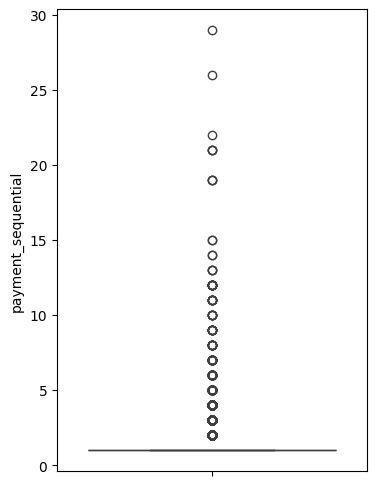

In [18]:
plt.figure(figsize=(4,6))
sns.boxplot(y=df['payment_sequential'])
plt.show()

In [19]:
df['payment_sequential'] = df['payment_sequential'].fillna(df['payment_sequential'].median())

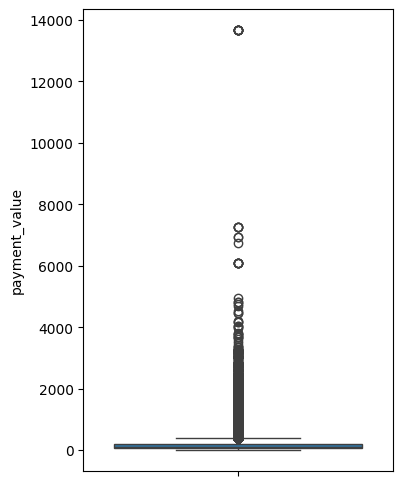

In [20]:
plt.figure(figsize=(4,6))
sns.boxplot(y=df['payment_value'])
plt.show()

In [21]:
df['payment_value'] = df['payment_value'].fillna(df['payment_value'].median())

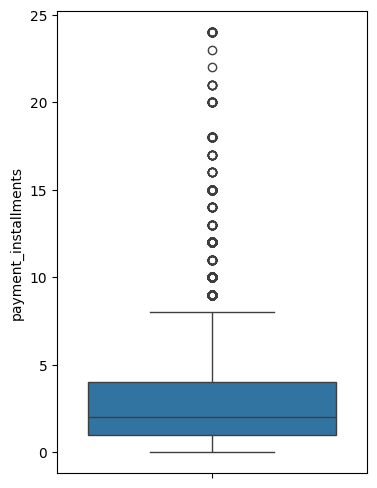

In [22]:
plt.figure(figsize=(4,6))
sns.boxplot(y=df['payment_installments'])
plt.show()

In [23]:
df['payment_installments'] = df['payment_installments'].fillna(df['payment_installments'].mean())

### Untuk kategorikal semua diimpute menggunakan unknown

In [24]:
df['payment_type'] = df['payment_type'].fillna('unknown')
df['seller_city'] = df['seller_city'].fillna('unknown')
df['seller_state'] = df['seller_state'].fillna('unknown')

In [58]:
df.to_csv("dataset.csv", index=False)
# dataset yang telah digabung

In [26]:
df = pd.read_csv("dataset.csv")
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_installments,payment_value,payment_type,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350.0,maua,SP,3.0,1.0,38.71,"credit_card, voucher",4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,31570.0,belo horizonte,SP,1.0,1.0,141.46,boleto,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,14840.0,guariba,SP,1.0,3.0,179.12,credit_card,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,31842.0,belo horizonte,MG,1.0,1.0,72.20,credit_card,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,8752.0,mogi das cruzes,SP,1.0,1.0,28.62,credit_card,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [59]:
df['delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['delay_days'] #menciptakan kolom baru untuk kepentingan analisis

0         -8
1         -6
2        -18
3        -13
4        -10
          ..
113420    -2
113421    -6
113422   -21
113423   -21
113424   -18
Name: delay_days, Length: 109369, dtype: int64

# Insight

## Problem Identification

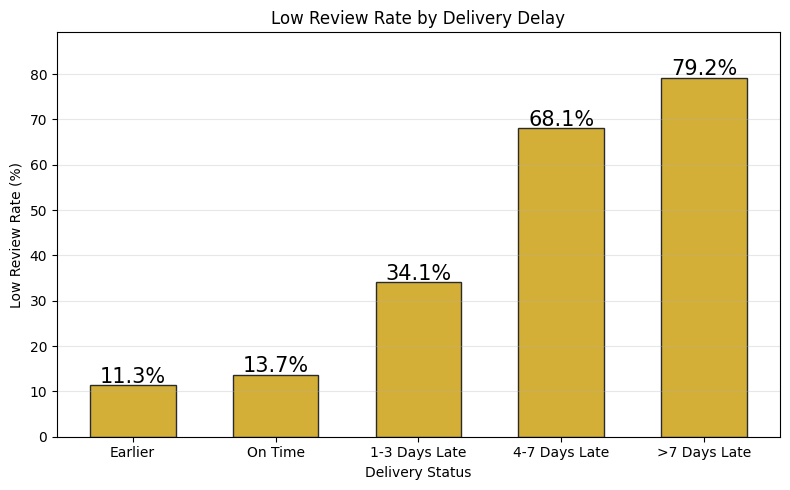

In [ ]:
df['low_review'] = df['review_score'].isin([1, 2]) #ambil review rendah

# Hitung persentase review rendah tiap kategori delay
delay_rate = (
    df.groupby('delay_category', observed=False)['low_review']
      .mean()
      .mul(100)
      .reindex([
          'Earlier',
          'On Time',
          '1-3 Days Late',
          '4-7 Days Late',
          '>7 Days Late'
      ])
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    delay_rate.index,
    delay_rate.values,
    color='#D4AF37', 
    edgecolor='#2B2B2B', 
    width=0.6 
)

# label persentase
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        fontsize=15,
        ha='center'
    )

plt.title('Low Review Rate by Delivery Delay')
plt.xlabel('Delivery Status')
plt.ylabel('Low Review Rate (%)')
plt.ylim(0, delay_rate.max() + 10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Insight #1

In [ ]:
df['delay_category'] = pd.cut( #mengkategorikan delay kedalam beberapa kategori
    df['delay_days'],
    bins=[-999,-1,0,3,7,999],
    labels=[
        'Earlier',
        'On Time',
        '1-3 Days Late',
        '4-7 Days Late',
        '>7 Days Late'
    ]
)

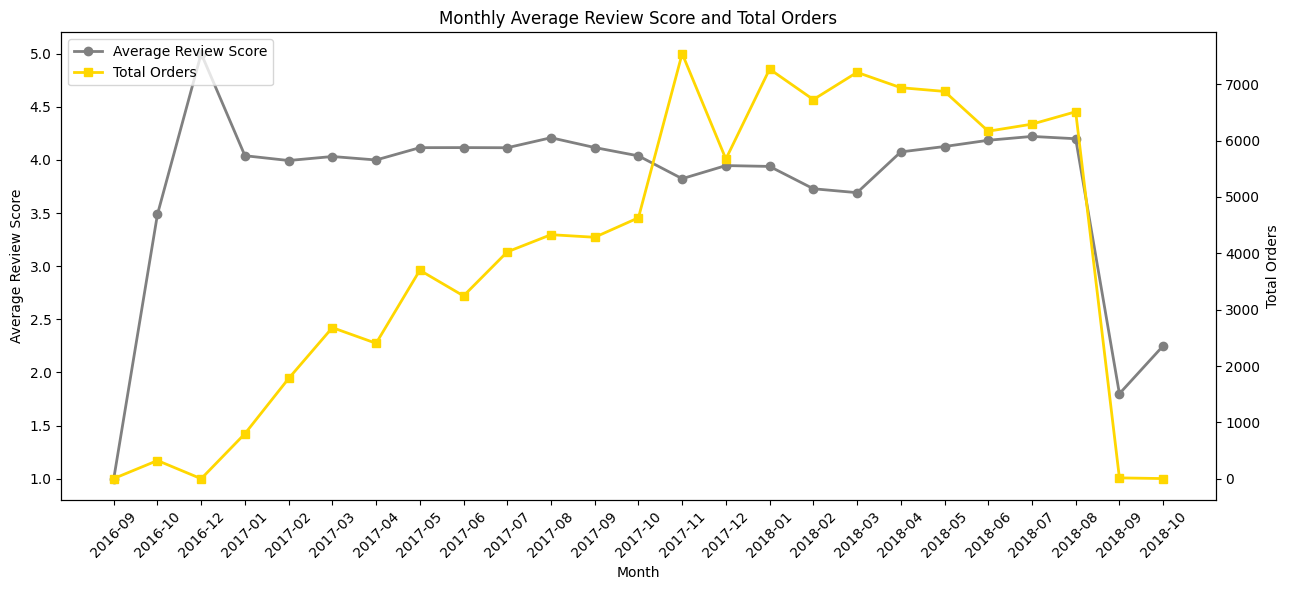

In [ ]:
# Ambil bulan
df['month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Agregasi
monthly = (
    df.groupby('month')
      .agg(
          avg_review=('review_score', 'mean'),
          total_orders=('order_id', 'nunique')
      )
      .reset_index()
)

# Plot
fig, ax1 = plt.subplots(figsize=(13,6))

# Review Score
ax1.plot(monthly['month'],
         monthly['avg_review'],
         marker='o',
         linewidth=2,
         color = 'gray',
         label='Average Review Score')

ax1.set_ylabel('Average Review Score')
ax1.set_xlabel('Month')
ax1.tick_params(axis='x', rotation=45)

# Order Count
ax2 = ax1.twinx()

ax2.plot(monthly['month'],
         monthly['total_orders'],
         marker='s',
         linewidth=2,
         color ='gold',
         label='Total Orders')

ax2.set_ylabel('Total Orders')

# Gabung legend
lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Monthly Average Review Score and Total Orders')
plt.tight_layout()
plt.show()

## Insight #2

In [ ]:
# Hanya order On Time / Earlier
ontime = df[df['delay_days'] <= 0].copy()

# Low review
ontime['low_review'] = ontime['review_score'].isin([1,2])

seller = (
    ontime
    .groupby('seller_id')
    .agg(
        total_orders=('order_id','count'),
        low_review_rate=('low_review','mean'),
        avg_review=('review_score','mean')
    )
)

# Minimal 30 order agar hasil analisis lebih akuratm dan tidak terkontaminasi dengan seller dengan 1-2 penjualan
seller = seller[seller['total_orders'] >= 30]

seller['low_review_rate'] *= 100

seller.sort_values(
    'low_review_rate',
    ascending=False
).head()

,total_orders,low_review_rate,avg_review
seller_id,,,
1ca7077d890b907f89be8c954a02686a,107,58.878505,2.429907
bb135baca94c82fcb731335ad5b04a03,38,52.631579,2.657895
2eb70248d66e0e3ef83659f71b244378,172,44.186047,2.904070
95f83f51203c626648c875dd41874c7f,63,42.857143,3.285714
8e6d7754bc7e0f22c96d255ebda59eba,116,42.241379,3.116379


In [ ]:
seller_consistency = ( #menghitung performa tiap seller
    ontime
    .groupby('seller_id')
    .agg(
        total_orders=('order_id','count'),
        avg_review=('review_score','mean'),
        std_review=('review_score','std'),
        low_review_rate=('low_review','mean')
    )
)

seller_consistency = seller_consistency[
    seller_consistency['total_orders'] >= 30
]

seller_consistency['low_review_rate'] *= 100 #persentaset dapat rating 1/2

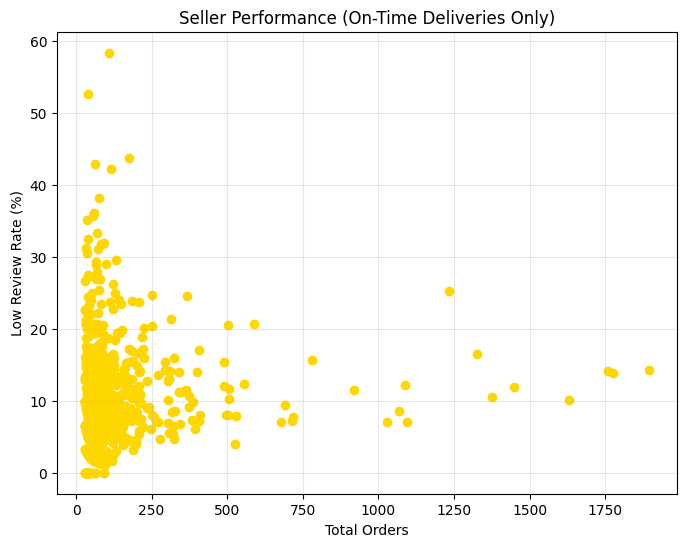

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    seller_consistency['total_orders'],
    seller_consistency['low_review_rate'],
    color='gold'
)

plt.xlabel('Total Orders')
plt.ylabel('Low Review Rate (%)')
plt.title('Seller Performance (On-Time Deliveries Only)')

plt.grid(alpha=0.3)
plt.show()

## Insight #3

In [56]:

# Buang baris yang datanya kosong di kolom-kolom penting
df = df.dropna(subset=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_score',
    'customer_state',
    'seller_state'
])

# Hitung selisih hari (positif = lebih cepat dari estimasi)
df['days_early'] = (df['order_estimated_delivery_date'] - df['order_delivered_customer_date']).dt.days

# Tandai apakah pengiriman beda provinsi atau satu provinsi
df['beda_provinsi'] = df['customer_state'] != df['seller_state']

# Agregasi: rata-rata hari lebih cepat & rata-rata review score per grup
grp = df.groupby('beda_provinsi').agg(
    avg_days_early=('days_early', 'mean'),
    avg_review_score=('review_score', 'mean')
).reindex([True, False])

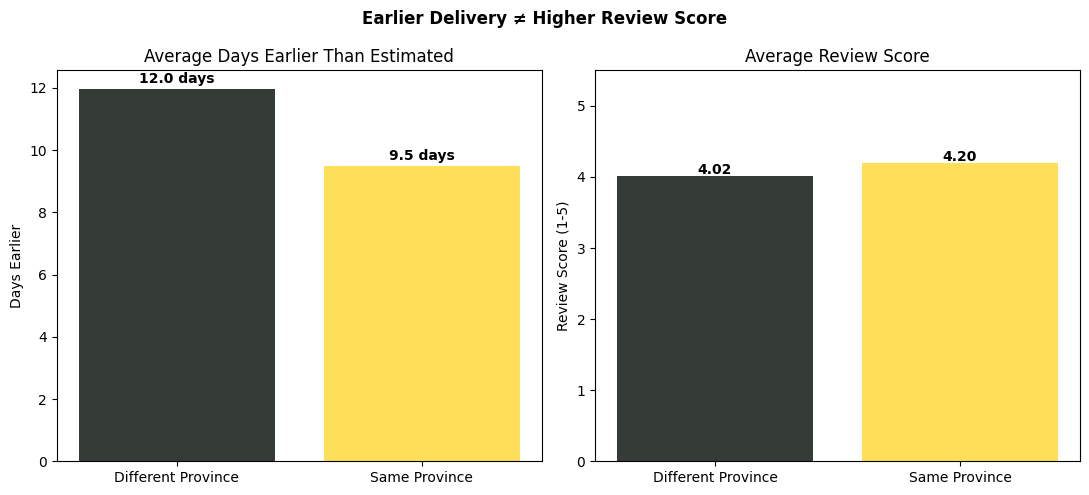

In [53]:
labels = ['Different Province', 'Same Province']
days_early = grp['avg_days_early'].values
scores = grp['avg_review_score'].values
colors = ["#353B36", "#FFDE59"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Panel kiri: rata-rata hari lebih cepat
axes[0].bar(labels, days_early, color=colors)
axes[0].set_title('Average Days Earlier Than Estimated')
axes[0].set_ylabel('Days Earlier')
for i, v in enumerate(days_early):
    axes[0].text(i, v + 0.2, f'{v:.1f} days', ha='center', fontweight='bold')

# Panel kanan: rata-rata review score
axes[1].bar(labels, scores, color=colors)
axes[1].set_title('Average Review Score')
axes[1].set_ylabel('Review Score (1-5)')
for i, v in enumerate(scores):
    axes[1].text(i, v + 0.03, f'{v:.2f}', ha='center', fontweight='bold')
axes[1].set_ylim(0, 5.5)

plt.suptitle('Earlier Delivery ≠ Higher Review Score', fontweight='bold')
plt.tight_layout()
plt.savefig('days_early_vs_score.png', dpi=150, bbox_inches='tight')

# Sumber Dataset
Olist, & Gaensly, L. Kaggle. Brazilian e-commerce public dataset by Olist [Data set]. Kaggle. https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce